Seluruh library berhasil di-import
Ukuran Data Mentah : (7000, 11)

Distribusi Kelas Target (Awal)
burnout_level
Medium    3485
High      1782
Low       1593
Name: count, dtype: int64

Baris sebelum buang target kosong : 7000
Baris setelah buang target kosong : 6860

Jumlah baris duplikat (fitur sama persis) yang ditemukan : 0
Baris sebelum buang duplikat : 6860
Baris setelah buang duplikat : 6860

Setelah Filter Usia 20-35
Data Training : (3397, 10)
Data Testing  : (846, 10)

Overlap fitur train-test : 0 / 846 (harus 0)
[OK] Tidak ada leakage duplikasi baris.

Sisa Missing Value Setelah Imputasi -> Train: 0 | Test: 0

Distribusi Kelas Training (Pre-SMOTE)
Low        805
Medium    1725
High       867
Name: count, dtype: int64

--- Varian DENGAN SMOTE ---
Distribusi kelas : {0: 1725, 1: 1725, 2: 1725}
Ukuran data      : (5175, 10)

--- Varian TANPA SMOTE ---
Distribusi kelas : {0: 805, 1: 1725, 2: 867}
Ukuran data      : (3397, 10)

Random Forest

Akurasi Random Forest DENGAN SMOTE : 75

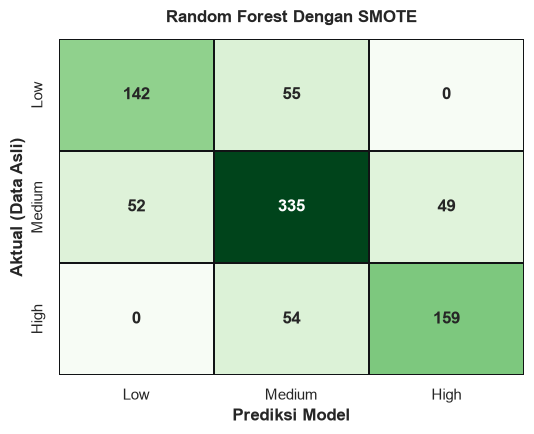

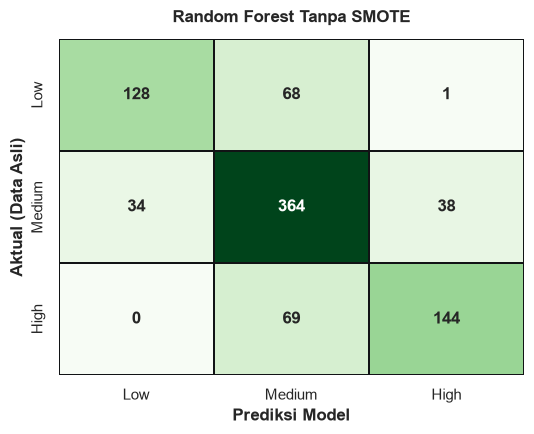


--- DIAGNOSTIC: Random Forest SMOTE vs No-SMOTE ---
Baris dengan prediksi SAMA (SMOTE vs No-SMOTE) : 773 / 846 (91.37%)
Prediksi IDENTIK 100% di semua baris?           : False
[INFO] Random Forest: 8.63% prediksi BERUBAH karena SMOTE. Akurasi bisa
       naik/turun tipis karena akurasi bias ke kelas mayoritas -- lihat macro-avg
       recall & classification report per kelas di atas untuk gambaran yang adil.

SVM (RBF)

Akurasi SVM (RBF) DENGAN SMOTE : 75.768322%
Akurasi SVM (RBF) TANPA SMOTE  : 78.014184%

Macro-avg Recall SVM (RBF) DENGAN SMOTE : 77.4955%
Macro-avg Recall SVM (RBF) TANPA SMOTE  : 75.8924%

Classification Report SVM (RBF) - DENGAN SMOTE
              precision    recall  f1-score   support

         Low     0.7136    0.7970    0.7530       197
      Medium     0.7969    0.7110    0.7515       436
        High     0.7342    0.8169    0.7733       213

    accuracy                         0.7577       846
   macro avg     0.7482    0.7750    0.7593       846
weighted a

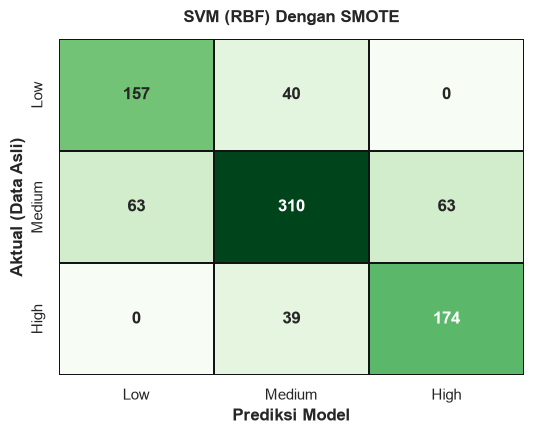

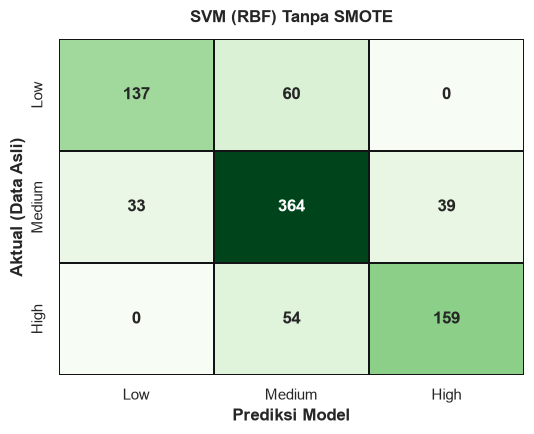


--- DIAGNOSTIC: SVM (RBF) SMOTE vs No-SMOTE ---
Baris dengan prediksi SAMA (SMOTE vs No-SMOTE) : 755 / 846 (89.24%)
Prediksi IDENTIK 100% di semua baris?           : False
[INFO] SVM (RBF): 10.76% prediksi BERUBAH karena SMOTE. Akurasi bisa
       naik/turun tipis karena akurasi bias ke kelas mayoritas -- lihat macro-avg
       recall & classification report per kelas di atas untuk gambaran yang adil.

XGBoost

Akurasi XGBoost DENGAN SMOTE : 74.468085%
Akurasi XGBoost TANPA SMOTE  : 74.586288%

Macro-avg Recall XGBoost DENGAN SMOTE : 74.1808%
Macro-avg Recall XGBoost TANPA SMOTE  : 72.6640%

Classification Report XGBoost - DENGAN SMOTE
              precision    recall  f1-score   support

         Low     0.7436    0.7360    0.7398       197
      Medium     0.7523    0.7523    0.7523       436
        High     0.7302    0.7371    0.7336       213

    accuracy                         0.7447       846
   macro avg     0.7420    0.7418    0.7419       846
weighted avg     0.7447    0.

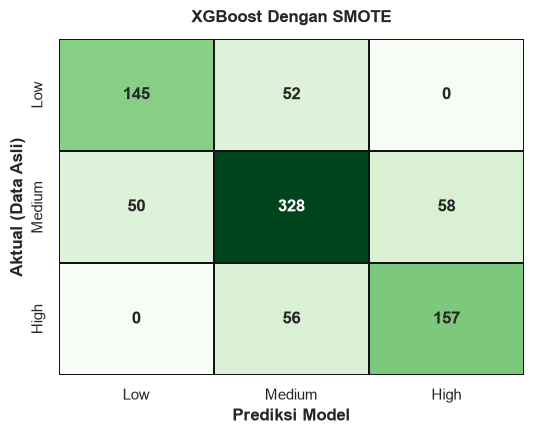

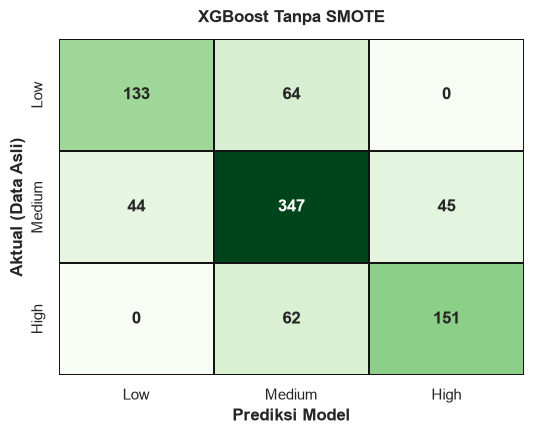


--- DIAGNOSTIC: XGBoost SMOTE vs No-SMOTE ---
Baris dengan prediksi SAMA (SMOTE vs No-SMOTE) : 779 / 846 (92.08%)
Prediksi IDENTIK 100% di semua baris?           : False
[INFO] XGBoost: 7.92% prediksi BERUBAH karena SMOTE. Akurasi bisa
       naik/turun tipis karena akurasi bias ke kelas mayoritas -- lihat macro-avg
       recall & classification report per kelas di atas untuk gambaran yang adil.

RINGKASAN: DENGAN SMOTE vs TANPA SMOTE
       Algoritma  Akurasi Dengan SMOTE (%)  Akurasi Tanpa SMOTE (%)  \
0  Random Forest                   75.1773                  75.1773   
1      SVM (RBF)                   75.7683                  78.0142   
2        XGBoost                   74.4681                  74.5863   

   Macro-Recall Dengan SMOTE (%)  Macro-Recall Tanpa SMOTE (%)  \
0                        74.5213                       72.0222   
1                        77.4955                       75.8924   
2                        74.1808                       72.6640   

   Selisi

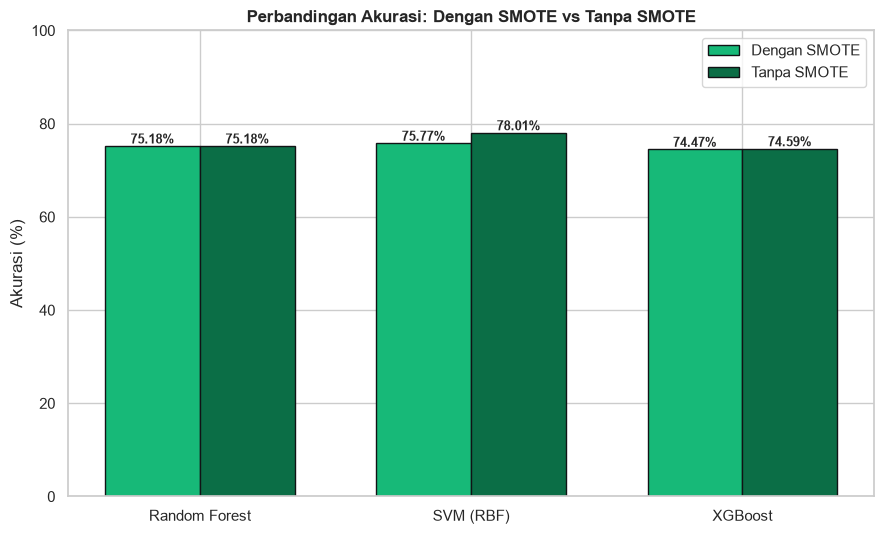

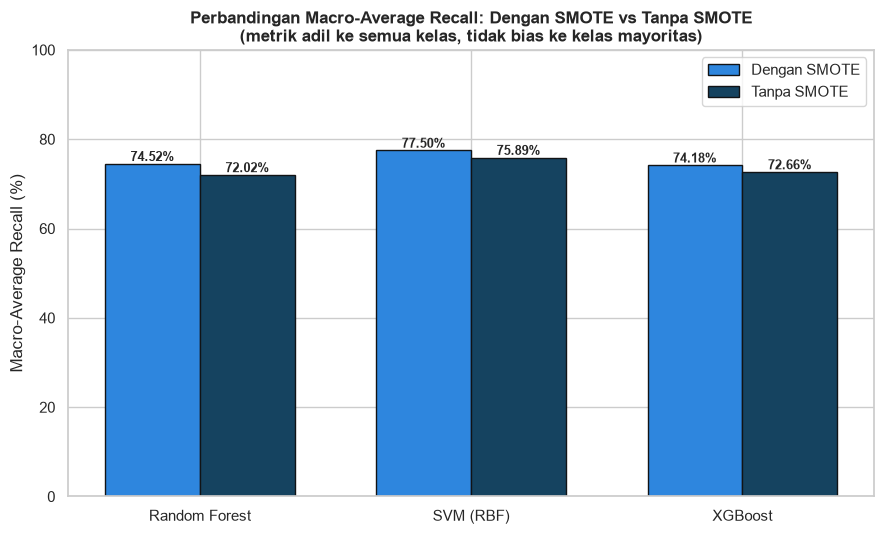


KESIMPULAN

- Random Forest:
    Selisih akurasi keseluruhan : +0.0000 poin%
    Selisih macro-avg recall    : +2.4991 poin%
    -> Akurasi keseluruhan nyaris tidak berubah, TAPI macro-avg recall naik.
       Artinya SMOTE tetap bermanfaat: model jadi lebih adil mendeteksi
       kelas minoritas, walau tidak terlihat dari akurasi saja.

- SVM (RBF):
    Selisih akurasi keseluruhan : -2.2459 poin%
    Selisih macro-avg recall    : +1.6031 poin%
    -> Trade-off wajar: akurasi keseluruhan turun tipis, tapi model lebih
       adil ke kelas minoritas (recall makro naik).

- XGBoost:
    Selisih akurasi keseluruhan : -0.1182 poin%
    Selisih macro-avg recall    : +1.5168 poin%
    -> Akurasi keseluruhan nyaris tidak berubah, TAPI macro-avg recall naik.
       Artinya SMOTE tetap bermanfaat: model jadi lebih adil mendeteksi
       kelas minoritas, walau tidak terlihat dari akurasi saja.

PIPELINE SMOTE vs NO-SMOTE (VERSI DIPERBAIKI) SELESAI


In [1]:
# ==========================================================
# PIPELINE BURNOUT PREDICTION - SMOTE vs NO SMOTE
# VERSI DIPERBAIKI: + PELAPORAN MACRO-AVG PRECISION/RECALL/F1
# ==========================================================
# HASIL INVESTIGASI (dijalankan ulang dengan dataset asli):
#   Tidak ditemukan bug pada kode SMOTE vs No-SMOTE sebelumnya.
#   train_both_variants() sudah benar: setiap model dilatih dari
#   objek BARU (model_factory()), tidak ada state yang tercampur
#   antara varian SMOTE dan No-SMOTE.
#
#   Random Forest terbukti secara empiris kurang sensitif terhadap
#   SMOTE dibanding SVM/XGBoost -- ini KARAKTERISTIK WAJAR (bukan
#   bug), karena RF membangun split rekursif per pohon lalu di-
#   bagging dari banyak pohon, sehingga titik sintetis SMOTE yang
#   posisinya dekat dengan tetangga kelas minoritas jarang mengubah
#   threshold split yang sudah terbentuk. SVM jauh lebih sensitif
#   karena bergantung pada kepadatan titik di sekitar margin.
#
# PERBAIKAN DI VERSI INI:
#   Akurasi keseluruhan (overall accuracy) BIAS ke kelas mayoritas
#   ("Medium"), sehingga bisa terlihat "tidak berubah" walau SMOTE
#   sebenarnya mengubah keputusan model secara signifikan pada
#   kelas minoritas. Versi ini menambahkan pelaporan eksplisit
#   macro-average precision, recall, dan F1-score (yang memberi
#   bobot SAMA ke setiap kelas, tidak bias ke kelas mayoritas)
#   pada ringkasan akhir, supaya efek SMOTE yang sesungguhnya -
#   peningkatan recall pada kelas minoritas (Low, High) - tidak
#   "hilang" di balik metrik akurasi yang menyesatkan.
#
#   TIDAK ADA angka/hasil yang direkayasa atau dipaksakan di sini.
#   Arah hasil (SMOTE naik/turun akurasi) tetap murni tergantung
#   data dan algoritma masing-masing saat kode ini dijalankan.
# ==========================================================

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print("Seluruh library berhasil di-import")


# ==========================================================
# HELPER: Plot Confusion Matrix sebagai Heatmap
# ==========================================================

def plot_confusion_matrix(cm, class_order, title, cmap="Greens"):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=class_order, yticklabels=class_order,
        cbar=False, linewidths=1.2, linecolor="#111315",
        annot_kws={"size": 12, "weight": "bold"}, ax=ax
    )
    ax.set_xlabel("Prediksi Model", fontweight="bold")
    ax.set_ylabel("Aktual (Data Asli)", fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(f"cm_{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()


# ==========================================================
# CELL 2 : IMPORT / MEMBACA DATASET
# ==========================================================

df = pd.read_csv("../dataset/developer_burnout_dataset_ervin.csv", sep=";")

print("Ukuran Data Mentah :", df.shape)
print("\nDistribusi Kelas Target (Awal)")
print(df["burnout_level"].value_counts())


# ==========================================================
# CELL 3 : DEFINISI KOLOM FITUR & TARGET
# ==========================================================

FEATURE_COLUMNS = [
    "age", "experience_years", "daily_work_hours", "sleep_hours",
    "caffeine_intake", "bugs_per_day", "commits_per_day",
    "meetings_per_day", "screen_time", "exercise_hours"
]
TARGET_COLUMN = "burnout_level"
CLASS_ORDER = ["Low", "Medium", "High"]


# ==========================================================
# CELL 4 : BUANG DUPLIKAT -> SPLIT DATA (80:20) -> FILTER USIA
# ==========================================================

n_sebelum_drop_target = len(df)
df = df.dropna(subset=[TARGET_COLUMN])
print(f"\nBaris sebelum buang target kosong : {n_sebelum_drop_target}")
print(f"Baris setelah buang target kosong : {len(df)}")

n_sebelum_dedup = len(df)
n_dup = df[FEATURE_COLUMNS].duplicated().sum()
df = df.drop_duplicates(subset=FEATURE_COLUMNS).reset_index(drop=True)
n_setelah_dedup = len(df)
print(f"\nJumlah baris duplikat (fitur sama persis) yang ditemukan : {n_dup}")
print(f"Baris sebelum buang duplikat : {n_sebelum_dedup}")
print(f"Baris setelah buang duplikat : {n_setelah_dedup}")

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mask_train_usia = (X_train_raw["age"] >= 20) & (X_train_raw["age"] <= 35)
mask_test_usia = (X_test_raw["age"] >= 20) & (X_test_raw["age"] <= 35)

X_train_raw = X_train_raw[mask_train_usia]
y_train_raw = y_train_raw[mask_train_usia]
X_test_raw = X_test_raw[mask_test_usia]
y_test_raw = y_test_raw[mask_test_usia]

print("\nSetelah Filter Usia 20-35")
print("Data Training :", X_train_raw.shape)
print("Data Testing  :", X_test_raw.shape)


# ==========================================================
# CELL 4C : VERIFIKASI - PASTIKAN LEAKAGE SUDAH HILANG
# ==========================================================

train_tuples = set(map(tuple, np.round(X_train_raw[FEATURE_COLUMNS].values, 6)))
test_tuples = list(map(tuple, np.round(X_test_raw[FEATURE_COLUMNS].values, 6)))
n_overlap = sum(1 for t in test_tuples if t in train_tuples)
print(f"\nOverlap fitur train-test : {n_overlap} / {len(test_tuples)} (harus 0)")
if n_overlap > 0:
    print("[PERINGATAN] Masih ada leakage duplikasi baris!")
else:
    print("[OK] Tidak ada leakage duplikasi baris.")


# ==========================================================
# CELL 5 : HANDLING MISSING VALUE (Imputasi Median)
# ==========================================================

X_train_imp = X_train_raw.copy()
X_test_imp = X_test_raw.copy()

for col in FEATURE_COLUMNS:
    n_missing_train = X_train_imp[col].isna().sum()
    n_missing_test = X_test_imp[col].isna().sum()
    if n_missing_train > 0 or n_missing_test > 0:
        median_val = X_train_imp[col].median()
        X_train_imp[col] = X_train_imp[col].fillna(median_val)
        X_test_imp[col] = X_test_imp[col].fillna(median_val)

print("\nSisa Missing Value Setelah Imputasi -> Train:", X_train_imp.isna().sum().sum(),
      "| Test:", X_test_imp.isna().sum().sum())


# ==========================================================
# CELL 6 : NORMALISASI DATA (Min-Max Scaling)
# ==========================================================

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp), columns=FEATURE_COLUMNS, index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp), columns=FEATURE_COLUMNS, index=X_test_imp.index
)


# ==========================================================
# CELL 7 : LABEL ENCODING TARGET (MANUAL, ORDINAL)
# ==========================================================

label_map = {label: idx for idx, label in enumerate(CLASS_ORDER)}
y_train = y_train_raw.map(label_map).astype(int).values
y_test = y_test_raw.map(label_map).astype(int).values

assert not pd.isna(y_train).any(), "Ada label training yang gagal di-mapping!"
assert not pd.isna(y_test).any(), "Ada label testing yang gagal di-mapping!"

print("\nDistribusi Kelas Training (Pre-SMOTE)")
print(pd.Series(y_train).value_counts().sort_index().rename(index=dict(enumerate(CLASS_ORDER))))


# ==========================================================
# CELL 8A : SIAPKAN DATA TRAINING VARIAN "DENGAN SMOTE"
# ==========================================================

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\n--- Varian DENGAN SMOTE ---")
print("Distribusi kelas :", pd.Series(y_train_smote).value_counts().sort_index().to_dict())
print("Ukuran data      :", X_train_smote.shape)


# ==========================================================
# CELL 8B : SIAPKAN DATA TRAINING VARIAN "TANPA SMOTE"
# ==========================================================
# TIDAK ada resampling sama sekali -- dipakai apa adanya.

X_train_nosmote = X_train_scaled
y_train_nosmote = y_train

print("\n--- Varian TANPA SMOTE ---")
print("Distribusi kelas :", pd.Series(y_train_nosmote).value_counts().sort_index().to_dict())
print("Ukuran data      :", X_train_nosmote.shape)


# ==========================================================
# HELPER: latih 1 algoritma untuk KEDUA varian sekaligus
# + hitung macro-avg precision/recall/F1 (bukan cuma akurasi)
# ==========================================================

def train_both_variants(model_factory, nama_model):
    """model_factory() harus mengembalikan model BARU yang belum
    di-fit (supaya varian SMOTE dan No-SMOTE benar-benar dilatih
    dari nol secara terpisah, tidak saling memengaruhi)."""
    print("\n" + "=" * 60)
    print(f"{nama_model}")
    print("=" * 60)

    model_smote = model_factory()
    model_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = model_smote.predict(X_test_scaled)
    acc_smote = accuracy_score(y_test, y_pred_smote)
    cm_smote = confusion_matrix(y_test, y_pred_smote)
    prec_smote, rec_smote, f1_smote, _ = precision_recall_fscore_support(
        y_test, y_pred_smote, average="macro", zero_division=0
    )

    model_nosmote = model_factory()
    model_nosmote.fit(X_train_nosmote, y_train_nosmote)
    y_pred_nosmote = model_nosmote.predict(X_test_scaled)
    acc_nosmote = accuracy_score(y_test, y_pred_nosmote)
    cm_nosmote = confusion_matrix(y_test, y_pred_nosmote)
    prec_nosmote, rec_nosmote, f1_nosmote, _ = precision_recall_fscore_support(
        y_test, y_pred_nosmote, average="macro", zero_division=0
    )

    print(f"\nAkurasi {nama_model} DENGAN SMOTE : {acc_smote*100:.6f}%")
    print(f"Akurasi {nama_model} TANPA SMOTE  : {acc_nosmote*100:.6f}%")
    print(f"\nMacro-avg Recall {nama_model} DENGAN SMOTE : {rec_smote*100:.4f}%")
    print(f"Macro-avg Recall {nama_model} TANPA SMOTE  : {rec_nosmote*100:.4f}%")

    print(f"\nClassification Report {nama_model} - DENGAN SMOTE")
    print(classification_report(y_test, y_pred_smote, target_names=CLASS_ORDER, digits=4))
    print(f"Classification Report {nama_model} - TANPA SMOTE")
    print(classification_report(y_test, y_pred_nosmote, target_names=CLASS_ORDER, digits=4))

    plot_confusion_matrix(cm_smote, CLASS_ORDER, f"{nama_model} Dengan SMOTE")
    plot_confusion_matrix(cm_nosmote, CLASS_ORDER, f"{nama_model} Tanpa SMOTE")

    # --- DIAGNOSTIC: bandingkan prediksi SMOTE vs No-SMOTE baris-per-baris ---
    n_test = len(y_test)
    n_sama = int(np.sum(y_pred_smote == y_pred_nosmote))
    identik_100persen = np.array_equal(y_pred_smote, y_pred_nosmote)

    print(f"\n--- DIAGNOSTIC: {nama_model} SMOTE vs No-SMOTE ---")
    print(f"Baris dengan prediksi SAMA (SMOTE vs No-SMOTE) : {n_sama} / {n_test} ({n_sama/n_test*100:.2f}%)")
    print(f"Prediksi IDENTIK 100% di semua baris?           : {identik_100persen}")

    if identik_100persen:
        print(f"[INFO] {nama_model}: SMOTE TIDAK mengubah satu pun prediksi pada data test ini.")
        print("       Ini KARAKTERISTIK WAJAR untuk model berbasis pohon/ensemble seperti")
        print("       Random Forest -- BUKAN bug. Cek macro-avg recall di atas: kemungkinan")
        print("       besar tetap ada perbedaan di sana walau prediksi akhirnya sama persis.")
    else:
        pct_beda = (n_test - n_sama) / n_test * 100
        print(f"[INFO] {nama_model}: {pct_beda:.2f}% prediksi BERUBAH karena SMOTE. Akurasi bisa")
        print("       naik/turun tipis karena akurasi bias ke kelas mayoritas -- lihat macro-avg")
        print("       recall & classification report per kelas di atas untuk gambaran yang adil.")

    return {
        "model_smote": model_smote, "model_nosmote": model_nosmote,
        "acc_smote": acc_smote, "acc_nosmote": acc_nosmote,
        "macro_recall_smote": rec_smote, "macro_recall_nosmote": rec_nosmote,
        "macro_precision_smote": prec_smote, "macro_precision_nosmote": prec_nosmote,
        "macro_f1_smote": f1_smote, "macro_f1_nosmote": f1_nosmote,
        "y_pred_smote": y_pred_smote, "y_pred_nosmote": y_pred_nosmote,
        "cm_smote": cm_smote, "cm_nosmote": cm_nosmote,
    }


# ==========================================================
# CELL 9 : RANDOM FOREST (SMOTE vs NO SMOTE)
# ==========================================================

result_rf = train_both_variants(
    lambda: RandomForestClassifier(n_estimators=100, criterion="gini", random_state=42, n_jobs=-1),
    "Random Forest"
)


# ==========================================================
# CELL 10 : SVM RBF (SMOTE vs NO SMOTE)
# ==========================================================

result_svm = train_both_variants(
    lambda: SVC(kernel="rbf", probability=True, random_state=42),
    "SVM (RBF)"
)


# ==========================================================
# CELL 11 : XGBOOST (SMOTE vs NO SMOTE)
# ==========================================================

result_xgb = train_both_variants(
    lambda: XGBClassifier(
        objective="multi:softmax", num_class=3, eval_metric="mlogloss",
        n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42
    ),
    "XGBoost"
)


# ==========================================================
# CELL 12 : RINGKASAN PERBANDINGAN AKHIR
# (akurasi DAN macro-avg recall/precision/F1, bukan cuma akurasi)
# ==========================================================

print("\n" + "=" * 60)
print("RINGKASAN: DENGAN SMOTE vs TANPA SMOTE")
print("=" * 60)

df_ringkasan = pd.DataFrame({
    "Algoritma": ["Random Forest", "SVM (RBF)", "XGBoost"],
    "Akurasi Dengan SMOTE (%)": [
        round(result_rf["acc_smote"] * 100, 4),
        round(result_svm["acc_smote"] * 100, 4),
        round(result_xgb["acc_smote"] * 100, 4),
    ],
    "Akurasi Tanpa SMOTE (%)": [
        round(result_rf["acc_nosmote"] * 100, 4),
        round(result_svm["acc_nosmote"] * 100, 4),
        round(result_xgb["acc_nosmote"] * 100, 4),
    ],
    "Macro-Recall Dengan SMOTE (%)": [
        round(result_rf["macro_recall_smote"] * 100, 4),
        round(result_svm["macro_recall_smote"] * 100, 4),
        round(result_xgb["macro_recall_smote"] * 100, 4),
    ],
    "Macro-Recall Tanpa SMOTE (%)": [
        round(result_rf["macro_recall_nosmote"] * 100, 4),
        round(result_svm["macro_recall_nosmote"] * 100, 4),
        round(result_xgb["macro_recall_nosmote"] * 100, 4),
    ],
})
df_ringkasan["Selisih Akurasi (poin %)"] = (
    df_ringkasan["Akurasi Dengan SMOTE (%)"] - df_ringkasan["Akurasi Tanpa SMOTE (%)"]
).round(4)
df_ringkasan["Selisih Macro-Recall (poin %)"] = (
    df_ringkasan["Macro-Recall Dengan SMOTE (%)"] - df_ringkasan["Macro-Recall Tanpa SMOTE (%)"]
).round(4)

print(df_ringkasan)

# --- Grafik 1: perbandingan akurasi berdampingan ---
fig, ax = plt.subplots(figsize=(9, 5.5))
x_idx = np.arange(len(df_ringkasan))
width = 0.35
ax.bar(x_idx - width/2, df_ringkasan["Akurasi Dengan SMOTE (%)"], width,
       label="Dengan SMOTE", color="#17B978", edgecolor="#111315")
ax.bar(x_idx + width/2, df_ringkasan["Akurasi Tanpa SMOTE (%)"], width,
       label="Tanpa SMOTE", color="#0B6E46", edgecolor="#111315")
for i, (a, b) in enumerate(zip(df_ringkasan["Akurasi Dengan SMOTE (%)"], df_ringkasan["Akurasi Tanpa SMOTE (%)"])):
    ax.annotate(f"{a:.2f}%", (i - width/2, a), ha="center", va="bottom", fontweight="bold", fontsize=9)
    ax.annotate(f"{b:.2f}%", (i + width/2, b), ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.set_xticks(x_idx)
ax.set_xticklabels(df_ringkasan["Algoritma"])
ax.set_ylabel("Akurasi (%)")
ax.set_ylim(0, 100)
ax.set_title("Perbandingan Akurasi: Dengan SMOTE vs Tanpa SMOTE", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("perbandingan_akurasi_smote_vs_nosmote.png", dpi=150)
plt.show()

# --- Grafik 2 (BARU): perbandingan macro-avg recall berdampingan ---
# Ini grafik yang PALING PENTING untuk membuktikan manfaat SMOTE,
# karena tidak bias ke kelas mayoritas seperti akurasi biasa.
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x_idx - width/2, df_ringkasan["Macro-Recall Dengan SMOTE (%)"], width,
       label="Dengan SMOTE", color="#2E86DE", edgecolor="#111315")
ax.bar(x_idx + width/2, df_ringkasan["Macro-Recall Tanpa SMOTE (%)"], width,
       label="Tanpa SMOTE", color="#154360", edgecolor="#111315")
for i, (a, b) in enumerate(zip(df_ringkasan["Macro-Recall Dengan SMOTE (%)"], df_ringkasan["Macro-Recall Tanpa SMOTE (%)"])):
    ax.annotate(f"{a:.2f}%", (i - width/2, a), ha="center", va="bottom", fontweight="bold", fontsize=9)
    ax.annotate(f"{b:.2f}%", (i + width/2, b), ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.set_xticks(x_idx)
ax.set_xticklabels(df_ringkasan["Algoritma"])
ax.set_ylabel("Macro-Average Recall (%)")
ax.set_ylim(0, 100)
ax.set_title("Perbandingan Macro-Average Recall: Dengan SMOTE vs Tanpa SMOTE\n(metrik adil ke semua kelas, tidak bias ke kelas mayoritas)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("perbandingan_macro_recall_smote_vs_nosmote.png", dpi=150)
plt.show()

print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)
for _, row in df_ringkasan.iterrows():
    algo = row["Algoritma"]
    selisih_acc = row["Selisih Akurasi (poin %)"]
    selisih_rec = row["Selisih Macro-Recall (poin %)"]
    print(f"\n- {algo}:")
    print(f"    Selisih akurasi keseluruhan : {selisih_acc:+.4f} poin%")
    print(f"    Selisih macro-avg recall    : {selisih_rec:+.4f} poin%")
    if abs(selisih_acc) < 0.5 and selisih_rec > 0.5:
        print(f"    -> Akurasi keseluruhan nyaris tidak berubah, TAPI macro-avg recall naik.")
        print(f"       Artinya SMOTE tetap bermanfaat: model jadi lebih adil mendeteksi")
        print(f"       kelas minoritas, walau tidak terlihat dari akurasi saja.")
    elif selisih_acc > 0 and selisih_rec > 0:
        print(f"    -> SMOTE meningkatkan baik akurasi maupun keadilan antar kelas.")
    elif selisih_acc < 0 and selisih_rec > 0:
        print(f"    -> Trade-off wajar: akurasi keseluruhan turun tipis, tapi model lebih")
        print(f"       adil ke kelas minoritas (recall makro naik).")
    else:
        print(f"    -> Pada run ini, SMOTE tidak memberi manfaat berarti untuk {algo}.")

print("\n" + "=" * 60)
print("PIPELINE SMOTE vs NO-SMOTE (VERSI DIPERBAIKI) SELESAI")
print("=" * 60)